# Python 
## Modulo - 3: Prova Finale 


<img src="https://www.laramind.com/blog/wp-content/uploads/2018/10/python-logo.jpg" width="600">

Il **committente** richiede di avere un **report** su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare i **dati, raccolti e curati da *Our World in Data***, all'indirizzo https://github.com/owid/covid-19-data/tree/master/public/data dove si trovano le informazioni relative. 

A tal proposito il seguente file di Jupiter Notebook riporterà step by step i punti richiesti dal committente. 


# Svolgimento dei punti richiesti


<img src="https://dayone.change-media.it/wp-content/uploads/2023/02/data-analytics.jpg" width="600">

Come prima cosa, **procedo a scaricare i dati** dal file csv indicato dal committente.                      
Creo quindi prima **l'URL** e successivamente procedo al caricamento dei dati nel **dataframe "Covid19"**.           
Per visualizzare le prime 5 righe della tabella utilizzo **il metodo** head(), così da avere una primissima idea della struttura del dataframe. 

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"
Covid19 = pd.read_csv(url)
print(Covid19.head())

  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-01-05          0.0        0.0   
1      AFG      Asia  Afghanistan  2020-01-06          0.0        0.0   
2      AFG      Asia  Afghanistan  2020-01-07          0.0        0.0   
3      AFG      Asia  Afghanistan  2020-01-08          0.0        0.0   
4      AFG      Asia  Afghanistan  2020-01-09          0.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           0.0         0.0                  NaN  ...   
1                 NaN           0.0         0.0                  NaN  ...   
2                 NaN           0.0         0.0                  NaN  ...   
3                 NaN           0.0         0.0                  NaN  ...   
4                 NaN           0.0         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0           NaN            

<img src="https://cdn-icons-png.flaticon.com/128/3840/3840653.png" width="100">

# Punto 1

**Nel primo step, procedo a scaricare i dati dal file csv indicato dal committente.**

Utilizzerò **l'attributo** shape per ottenere informazioni riguardo **righe e colonne** e in seguito il **metodo** info() per avere informazioni riguardo i **metadati**.

In [3]:
Covid19.shape

(429435, 67)

In [4]:
Covid19.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

<img src="https://cdn-icons-png.flaticon.com/128/13476/13476422.png" width="100">

# Punto 2



2. Si chiede di trovare, per ogni continente:
   
    a. **il numero di casi fin dall'inizio della pandemia**
   
    b. **la percentuale rispetto al totale mondiale del numero di casi**


Prima di svolgere i punti ho effettuato una verifica delle colonne continente e stato(location) per capire se tutto fosse riportato nella maniera corretta. Ho quindi estratto tutti **i nomi unici** presenti nella colonna **location**, confermando che la colonna contiene degli intrusi come Asia, Europa o Low income countries. Ho fatto una verifica isolando specificamente la riga dove la location è "Asia" per vedere cosa c'è scritto nella sua colonna `continent. Ho ottenuto come output per "Asia" NaN mentre per la location "Italy" nella colonna continent ottengo Europe. **se la location è un aggregato (come l'Asia), la colonna continent è vuota**. 
Infine ho fatto una verifica sui new cases, sommandoli viene un numero molto alto (troppo), per cui conferma che dentro ci sono anche dei dati cumulati. 

   

In [5]:
print(Covid19['location'].unique())
print(Covid19[Covid19['location'] == 'Asia'][['location', 'continent']])
print(Covid19[Covid19['location'] == 'Italy'][['location', 'continent']])
print(Covid19['new_cases'].sum())

['Afghanistan' 'Africa' 'Albania' 'Algeria' 'American Samoa' 'Andorra'
 'Angola' 'Anguilla' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Asia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain'
 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda'
 'Bhutan' 'Bolivia' 'Bonaire Sint Eustatius and Saba'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon'
 'Canada' 'Cape Verde' 'Cayman Islands' 'Central African Republic' 'Chad'
 'Chile' 'China' 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica'
 "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus' 'Czechia'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'East Timor' 'Ecuador' 'Egypt' 'El Salvador'
 'England' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Europe' 'European Union (27)' 'Faroe Islands' 'Falkland Islands' 'Fiji'
 'Finland' 'France' 'French Guiana' 'Fr

<img src="https://cdn-icons-png.flaticon.com/128/4115/4115891.png" width="100">

Ho poi fatto un **confronto tra new cases e total cases**, per capire la differenza tra le due colonne. 
Dall'analisi esplorativa effettuata sull'Italia, si osserva che la somma della colonna `new_cases` coincide perfettamente con il valore massimo della colonna `total_cases`. Questo dimostra che la colonna total cases riporta dei dati cumulativi, quindi procedere per aggregazione e somma con la colonna total cases non è corretto, ma dovrebbe essere utilizzato il massimo valore. 
**New cases riporta valori puntuali, total cases valori cumulati.** Ho fatto un test utilizzando l'italia come campione. 

In [6]:
italia = Covid19[Covid19['location'] == 'Italy']

metodo_somma = italia['new_cases'].sum()
metodo_cumulativo = italia['total_cases'].max()
print(metodo_somma) 
print(metodo_cumulativo)

26781078.0
26781078.0


<img src="https://cdn-icons-png.flaticon.com/128/4115/4115891.png" width="100">


A questo punto per svolgere il **punto a** ho ragionato in questo modo: 
1. Ho tenuto solo le righe che si riferiscono a nazioni reali, eliminando quelle in cui continent era NaN.
2. Ho sommato i nuovi casi registrati giorno per giorno per ottenere il totale storico di ogni nazione, infine ho raggruppato per location. 
3. Ho sommato i valori raggruppandoli  solo per continente. 

In [7]:
nazioni = Covid19.dropna(subset=['continent'])
print(nazioni)
casi_per_nazione = nazioni.groupby(['continent', 'location'])['new_cases'].sum().reset_index()
casi_per_nazione
casi_per_continente = casi_per_nazione.groupby('continent')['new_cases'].sum()
casi_per_continente

       iso_code continent     location        date  total_cases  new_cases  \
0           AFG      Asia  Afghanistan  2020-01-05          0.0        0.0   
1           AFG      Asia  Afghanistan  2020-01-06          0.0        0.0   
2           AFG      Asia  Afghanistan  2020-01-07          0.0        0.0   
3           AFG      Asia  Afghanistan  2020-01-08          0.0        0.0   
4           AFG      Asia  Afghanistan  2020-01-09          0.0        0.0   
...         ...       ...          ...         ...          ...        ...   
429430      ZWE    Africa     Zimbabwe  2024-07-31     266386.0        0.0   
429431      ZWE    Africa     Zimbabwe  2024-08-01     266386.0        0.0   
429432      ZWE    Africa     Zimbabwe  2024-08-02     266386.0        0.0   
429433      ZWE    Africa     Zimbabwe  2024-08-03     266386.0        0.0   
429434      ZWE    Africa     Zimbabwe  2024-08-04     266386.0        0.0   

        new_cases_smoothed  total_deaths  new_deaths  new_death

continent
Africa            13146831.0
Asia             301564180.0
Europe           252916868.0
North America    124492698.0
Oceania           15003468.0
South America     68811012.0
Name: new_cases, dtype: float64

<img src="https://cdn-icons-png.flaticon.com/128/11083/11083341.png" width="100">



Per svolgere il **punto b**: 
1.  Ho sommato i risultati dei continenti per ottenere il numero dei casi nel mondo 
2. Ho diviso i singoli continenti sul totale nel mondo
3. Ho inserito in un dataframe così da avere una visuale più chiara dove ottengo continente, valore totale e valore percentuale rispetto ai casi mondiali. 

In [8]:
totale_mondiale = casi_per_continente.sum()
totale_mondiale
percentuali = (casi_per_continente / totale_mondiale) * 100
percentuali

continent
Africa            1.694321
Asia             38.864616
Europe           32.595108
North America    16.044216
Oceania           1.933598
South America     8.868141
Name: new_cases, dtype: float64

In [9]:
report_continenti = pd.DataFrame({
    'Casi Totali': casi_per_continente,
    'Percentuale (%)': percentuali
})
report_continenti

,Casi Totali,Percentuale (%)
continent,,
Africa,13146831.0,1.694321
Asia,301564180.0,38.864616
Europe,252916868.0,32.595108
North America,124492698.0,16.044216
Oceania,15003468.0,1.933598
South America,68811012.0,8.868141


<img src="https://cdn-icons-png.flaticon.com/128/5359/5359895.png" width="100">


Nello svolgimento del punto a e del punto b ho fatto due prove, una utilizzando il massimo di total cases e una la somma di new cases (nonostante nel caso prova "italia" fossero uguali). I numeri ottenuti erano nettamente diversi, quindi sulla base della coerenza nei dati, ho optato per l'utilizzo della registrazione dei dati puntuali nella colonna newcases e non dei dati cumulativi, in quanto nel recording dei dati cumulativi gli stati possono avere tralasciato il tracciamento, mentre nella colonna new cases i dati sono più precisi dandoci un quadro più puntuale. 

<img src="https://cdn-icons-png.flaticon.com/128/3840/3840739.png" width="100">

# Punto 3


Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati:

     a. l'evoluzione dei casi totali dall'inizio alla fine dell'anno 

     b. il numero di nuovi casi rispetto alla data

Per svolgere il punto a ho quindi creato una copia del dataset chiamandola italia_2022 dove appunto ho filtrato il dataset per location = Italy e date 2022, poi ho convertito la date in formato datetime, infine ho creato italia_2022_pulito dove ho eliminato le righe (già filtrate per italia e anno) dove new cases è vuoto, perchè ci sono alcuni giorni dove non è stato caricato il numero. 


In [10]:
italia_2022 = Covid19[(Covid19['location'] == 'Italy') & (Covid19['date'].str.contains('2022'))].copy()
italia_2022['date'] = pd.to_datetime(italia_2022['date'])
italia_2022_pulito = italia_2022.dropna(subset=['new_cases'])

italia_2022_pulito

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
186002,ITA,Europe,Italy,2022-01-01,5622431.0,0.0,36797.00,136530.0,0.0,140.86,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186003,ITA,Europe,Italy,2022-01-02,6267035.0,644604.0,92086.29,137513.0,983.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,168226.3,12.99,8.06,2849.48
186004,ITA,Europe,Italy,2022-01-03,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186005,ITA,Europe,Italy,2022-01-04,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186006,ITA,Europe,Italy,2022-01-05,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186362,ITA,Europe,Italy,2022-12-27,25060503.0,0.0,18918.14,184168.0,0.0,114.00,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186363,ITA,Europe,Italy,2022-12-28,25060503.0,0.0,18918.14,184168.0,0.0,114.00,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186364,ITA,Europe,Italy,2022-12-29,25060503.0,0.0,18918.14,184168.0,0.0,114.00,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186365,ITA,Europe,Italy,2022-12-30,25060503.0,0.0,18918.14,184168.0,0.0,114.00,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN


<img src="https://cdn-icons-png.flaticon.com/128/3281/3281306.png" width="100">


L'analisi dell'anno 2022 in Italia evidenzia due prospettive:

**Evoluzione Casi Totali**: L'utilizzo del dato cumulativo mostra la progressione della pandemia. La curva è  monotona crescente, poiché rappresenta la somma complessiva dei casi registrati dall'inizio dell'anno. Tratti più verticali corrispondono a fasi di forte contagio (come a inizio anno), mentre tratti più piatti indicano un rallentamento della diffusione del contagio stesso.

**Andamento Nuovi Casi**: La 'fotografia giornaliera' rivela una distribuzione molto più frammentata, con la caratteristica forma a pettine. Questa discontinuità è dovuta alla modalità di recording dei dati nel 2022, spesso concentrata in report settimanali che generano picchi seguiti da giorni in cui il numero è pari a zero. Nonostante questo rumore visivo, il grafico permette di individuare chiaramente le ondate pandemiche: è evidente come la concentrazione di contagi sia stata significativamente più alta nel primo trimestre del 2022 rispetto al resto dell'anno.

<img src="https://cdn-icons-png.flaticon.com/128/3840/3840753.png" width="100">

# Punto 4

Riguardo le nazioni di Italia, Germania, Francia:
a. mostrare in un **boxplot** la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso) 
b. scrivere un **breve commento** (una o due righe) riguardo che conclusioni possiamo trarre osservando il grafico risultante

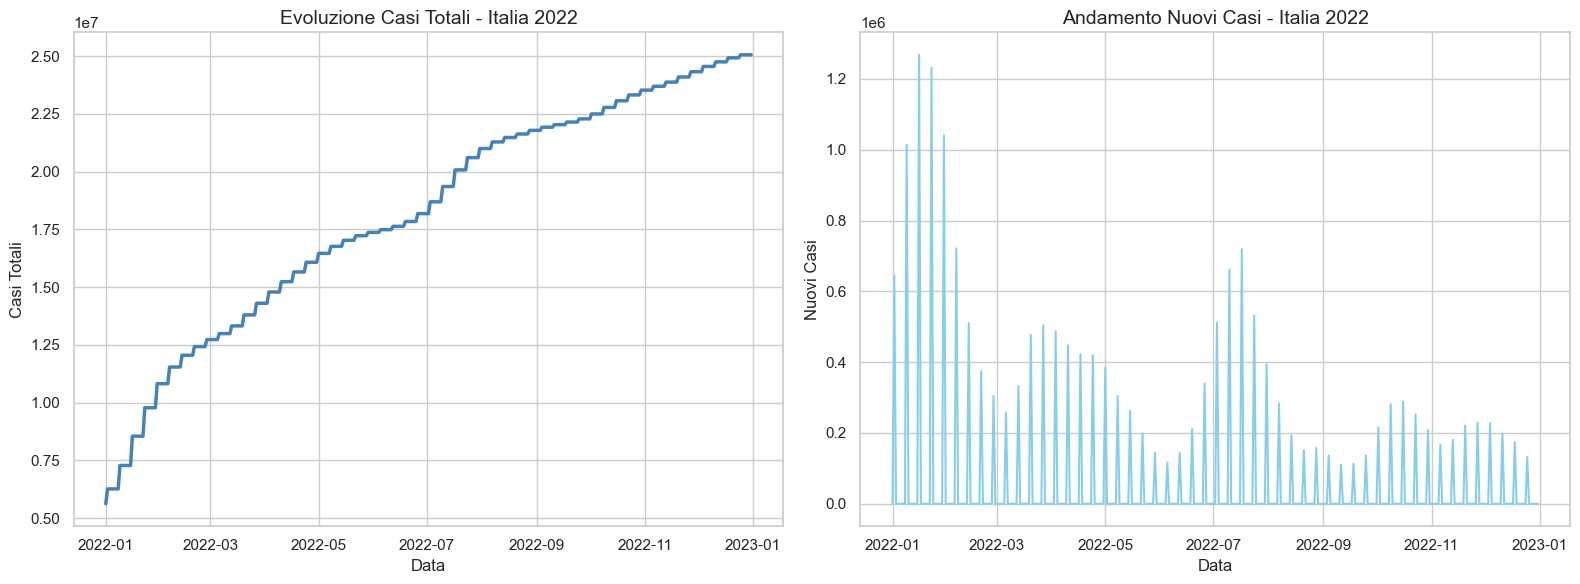

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data=italia_2022_pulito, x='date', y='total_cases', color='steelblue', linewidth=2.5)
plt.title('Evoluzione Casi Totali - Italia 2022', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Casi Totali')

plt.subplot(1, 2, 2)
sns.lineplot(data=italia_2022_pulito, x='date', y='new_cases', color='skyblue')
plt.title('Andamento Nuovi Casi - Italia 2022', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Nuovi Casi')

plt.tight_layout()
plt.show()

In [12]:
nazioni = ['Italy', 'Germany', 'France']

IT_GER_FRA = Covid19[
    (Covid19['location'].isin(nazioni)) & 
    (Covid19['date'] >= '2022-05-01') & 
    (Covid19['date'] <= '2023-04-30')
].copy()
print(IT_GER_FRA)

       iso_code continent location        date  total_cases  new_cases  \
131214      FRA    Europe   France  2022-05-01   27742592.0   376510.0   
131215      FRA    Europe   France  2022-05-02   27742592.0        0.0   
131216      FRA    Europe   France  2022-05-03   27742592.0        0.0   
131217      FRA    Europe   France  2022-05-04   27742592.0        0.0   
131218      FRA    Europe   France  2022-05-05   27742592.0        0.0   
...         ...       ...      ...         ...          ...        ...   
186482      ITA    Europe    Italy  2023-04-26   25772459.0        0.0   
186483      ITA    Europe    Italy  2023-04-27   25772459.0        0.0   
186484      ITA    Europe    Italy  2023-04-28   25772459.0        0.0   
186485      ITA    Europe    Italy  2023-04-29   25772459.0        0.0   
186486      ITA    Europe    Italy  2023-04-30   25795509.0    23050.0   

        new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  \
131214            53787.14      14

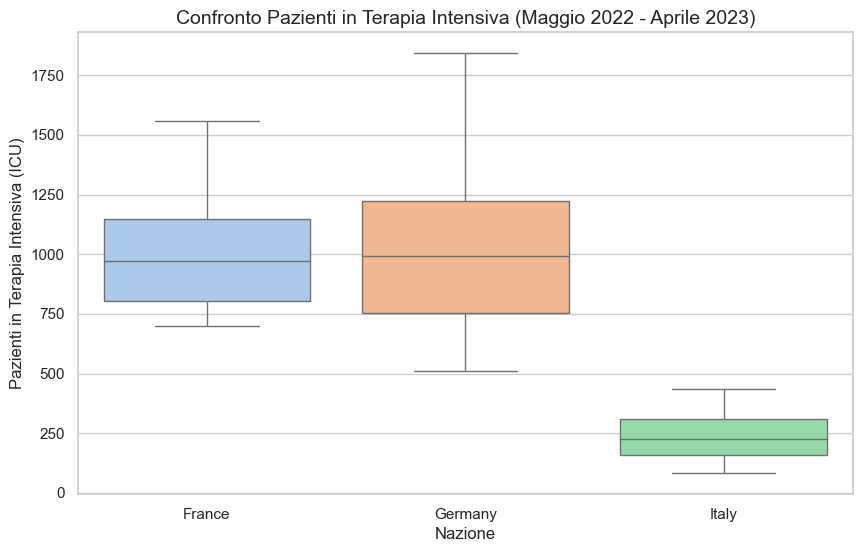

In [13]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.boxplot(data=IT_GER_FRA, x='location', y='icu_patients', hue='location', palette='pastel', legend=False)
plt.title('Confronto Pazienti in Terapia Intensiva (Maggio 2022 - Aprile 2023)', fontsize=14)
plt.xlabel('Nazione')
plt.ylabel('Pazienti in Terapia Intensiva (ICU)')

plt.show()

<img src="https://cdn-icons-png.flaticon.com/128/809/809460.png" width="100">


L'analisi statistica condotta attraverso il **boxplot** rivela **tre scenari sanitari** profondamente distinti per il periodo compreso tra maggio 2022 e aprile 2023.

L'**Italia** si distingue per la gestione più stabile e contenuta: rappresentata dalla scatola posizionata più in basso nel grafico, ha mantenuto il numero di pazienti in terapia intensiva costantemente sotto la soglia dei 500. 
La forma "schiacciata" del boxplot indica una bassissima variabilità dei dati; questo suggerisce che il sistema sanitario italiano non ha subito ondate di gravità tale da stravolgere l'occupazione dei posti letto, garantendo una continuità operativa durante tutto l'anno.

All'estremo opposto troviamo la **Germania**, che presenta il comportamento più volatile. Con la scatola più estesa e il "baffo" superiore più lungo del set di dati (prossimo ai 1800 pazienti), la Germania ha vissuto una gestione estremamente altalenante. L'altezza della scatola indica una forte differenza tra i periodi di stasi e i momenti di picco: il sistema ha dovuto affrontare situazioni di stress considerevoli, con picchi di ricoveri quasi quattro volte superiori a quelli registrati in Italia.

In una posizione intermedia si colloca la **Francia**. Sebbene la sua mediana (il valore centrale) sia molto vicina a quella tedesca — intorno ai 1000 pazienti — la struttura del suo boxplot è più compatta. Ciò indica che, sebbene la pressione sulle terapie intensive francesi sia stata numericamente elevata e costante, il sistema non ha subito gli sbalzi estremi osservati in Germania. In Francia, il carico di lavoro è stato dunque sistematicamente alto, ma più prevedibile e raggruppato attorno ai valori medi.

In conclusione, il confronto evidenzia come l'Italia abbia goduto di una situazione di pressione minima e costante, mentre Francia e Germania hanno gestito volumi di pazienti critici decisamente superiori, differenziandosi tra loro per la modalità di afflusso: costante per i francesi e fortemente irregolare per i tedeschi.

<img src="https://cdn-icons-png.flaticon.com/128/3840/3840754.png" width="100">

# Punto 5

Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:
   
  **a**.mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna   hosp_patients) 
  
  **b**. se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno

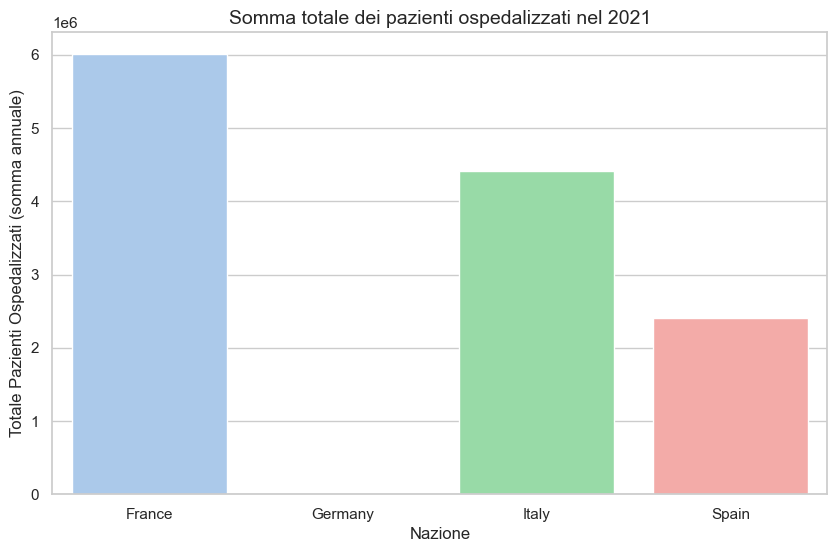

  location  hosp_patients
0   France      6008717.0
1  Germany            0.0
2    Italy      4419950.0
3    Spain      2411706.0


In [14]:
IT_GER_FRA_SPA = ['Italy', 'Germany', 'France', 'Spain']
IT_GER_FRA_SPA_2021 = Covid19[
    (Covid19['location'].isin(IT_GER_FRA_SPA)) & 
    (Covid19['date'] >= '2021-01-01') & 
    (Covid19['date'] <= '2021-12-31')
].copy()

somma_ospedalizzati = IT_GER_FRA_SPA_2021.groupby('location')['hosp_patients'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=somma_ospedalizzati, x='location', y='hosp_patients', hue='location', palette='pastel', legend=False)
plt.title('Somma totale dei pazienti ospedalizzati nel 2021', fontsize=14)
plt.ylabel('Totale Pazienti Ospedalizzati (somma annuale)')
plt.xlabel('Nazione')
plt.show()

print(somma_ospedalizzati)


In [16]:
df_2021 = Covid19[(Covid19['location'].isin(['Italy', 'Germany', 'France', 'Spain'])) & 
                  (Covid19['date'].str.contains('2021'))]

print("Dati nulli in Italia:", df_2021[df_2021['location'] == 'Italy']['hosp_patients'].isnull().sum())
print("Dati nulli in Germania:", df_2021[df_2021['location'] == 'Germany']['hosp_patients'].isnull().sum())
print("Dati nulli in Francia:", df_2021[df_2021['location'] == 'France']['hosp_patients'].isnull().sum())
print("Dati nulli in Spagna:", df_2021[df_2021['location'] == 'Spain']['hosp_patients'].isnull().sum())

Dati nulli in Italia: 0
Dati nulli in Germania: 365
Dati nulli in Francia: 0
Dati nulli in Spagna: 0


<img src="https://cdn-icons-png.flaticon.com/128/6863/6863897.png" width="100">


Dall'analisi dei dati mancanti per il 2021, emerge una situazione eterogenea: mentre Italia, Francia e Spagna presentano una serie storica completa (0 dati nulli), la Germania registra l'assenza totale di dati per la colonna hosp_patients (365 valori nulli).

Per quanto riguarda la gestione di tali lacune, **non è possibile intervenire tramite sostituzione**. Se per mancanze sporadiche si sarebbe potuto ipotizzare un'imputazione basata sulla media, nel caso della Germania l'assenza totale di informazioni rende impossibile ricostruire il dato in modo veritiero. Pertanto, l'analisi numerica della somma degli ospedalizzati potrà essere condotta in modo affidabile solo per Italia, Francia e Spagna, escludendo la Germania dal confronto quantitativo per evitare distorsioni nei risultati finali.




# Conclusioni Finali

Al termine di questa analisi, è possibile trarre le seguenti conclusioni:

1. **Integrità del Dataset**: La fase di auditing ha rivelato che la gestione dei dati COVID-19 non è uniforme a livello globale. Le lacune informative riscontrate (es. ospedalizzazioni in Germania) impongono un approccio prudente: è preferibile segnalare l'assenza del dato piuttosto che tentare sostituzioni statistiche che falserebbero la realtà epidemiologica.
2. **Dinamiche Nazionali**: L'Italia ha mostrato, nel periodo 2022-2023, una gestione dei reparti critici (ICU) più stabile rispetto ai partner europei, mantenendo i ricoveri costantemente sotto i 500 pazienti medi.
3. **Validazione Statistica**: Il progetto ha confermato l'importanza di distinguere tra variabili cumulative (`total_cases`) e puntuali (`new_cases`). L'uso corretto di operatori di aggregazione (Massimo vs Somma) è l'unico modo per evitare sovrastime massive dei contagi.

In sintesi, il report non descrive solo l'andamento del virus, ma sottolinea come la capacità di leggere correttamente i dati sia uno strumento indispensabile per interpretare fenomeni complessi.